In [7]:
from tensorflow.keras.datasets import mnist

In [8]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [9]:
train_images.shape

(60000, 28, 28)

In [10]:
test_images.shape

(10000, 28, 28)

In [11]:
train_labels[2]

np.uint8(4)

In [12]:
test_labels[1]

np.uint8(2)

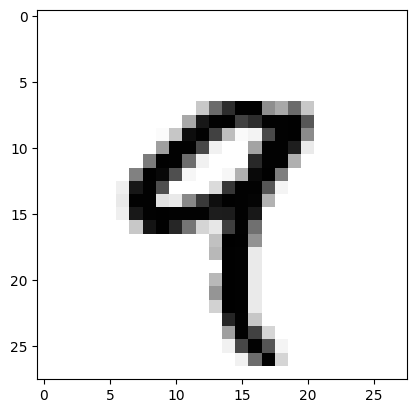

In [13]:
# check the imgs
import matplotlib.pyplot as plt
digit = train_images[4]
plt.imshow(digit,cmap=plt.cm.binary)
plt.show()

In [14]:
# Herr we are creating Neural Network Model
from tensorflow.keras import layers
from tensorflow import keras

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),  
    layers.Dense(10, activation='softmax')
])

c:\ArchTech_Internship\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Here the model tracks the loss and accuracy
model.compile(optimizer="rmsprop",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [16]:
# here reshaping the imgs and converting its data type 
train_images = train_images.reshape((60000, 784))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 784))
test_images = test_images.astype("float32") / 255

In [17]:
train_images.shape

(60000, 784)

In [18]:
# Here model learns all the parameters
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9219 - loss: 0.2699
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9685 - loss: 0.1074
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9786 - loss: 0.0710
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9851 - loss: 0.0513
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9890 - loss: 0.0372


In [19]:
# Here we are checking the performance of model on unseen data
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9817 - loss: 0.0605


In [20]:
test_loss

0.060484446585178375

In [21]:
test_acc

0.9817000031471252

In [22]:
test_digits=test_images[0:10]
prediction = model.predict(test_digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


In [23]:
for i in prediction:
    print(i.argmax())

7
2
1
0
4
1
4
9
5
9


In [24]:
test_labels[0:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

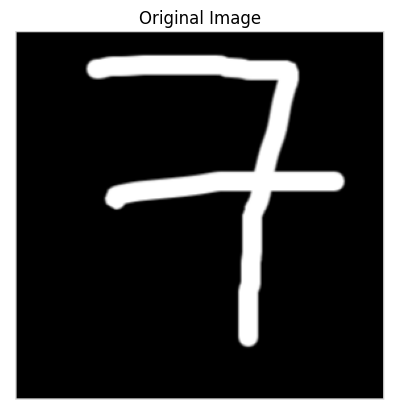

In [33]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img_path = r'seven.png'
original_image = Image.open(img_path)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

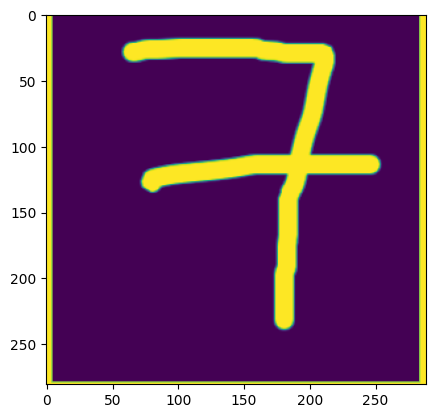

In [34]:
# Convert to grayscale and Resize 
grayscale_img = original_image.convert('L')
plt.imshow(grayscale_img)
# ✅ Resize to 28x28 (MNIST standard size)
grayscale_img = grayscale_img.resize((28, 28))

In [35]:
# Convert to numpy array and normalize
grayscale_array = np.array(grayscale_img) / 255.0
# ✅ Flatten to (1, 784)
grayscale_array = grayscale_array.reshape(1, 784)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


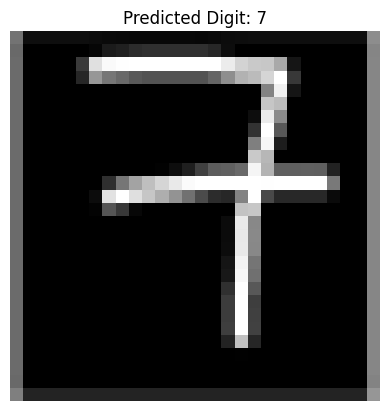

🧠 Model Prediction: 7


In [36]:
# --- Step 3: Predict ---
prediction = model.predict(grayscale_array)
predicted_digit = np.argmax(prediction)

# --- Step 4: Show Result ---
plt.imshow(grayscale_img, cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()

print(f"🧠 Model Prediction: {predicted_digit}")

In [32]:

model.save('mnist_model.h5')
print("Model saved as mnist_model.h5 ✅")

import tensorflow as tf

model = tf.keras.models.load_model("mnist_model.h5")

Model saved as mnist_model.h5 ✅
